# 四类步长模型比较：随机、邻近、跳跃、Levy

这个 notebook 用连续两次有效着色之间的转移来比较 4 个模型：

- `random`：当前所有可选目标等概率
- `neighbor`：优先选择当前度量下最短的步长
- `jump`：只要存在更长步长，就主动避开最短步长
- `levy`：步长满足幂律权重 `P(L) \propto L^{-\mu}`，并对 `1 < \mu < 3` 拟合 `\mu`

这里会分别在两种步长定义下做模型比较：

- 图上的步长：相邻区域图上的最短路长度
- 欧氏步长：两个区域质心之间的欧氏距离

主分析口径：对每一种步长定义，直接把 `所有被试 × 所有正式 round × 所有有效转移步` 合并起来，拟合整个分布的 likelihood；不先在被试或图上做平均。

说明：对 `neighbor` / `jump`，这里采用统一定义“相对于当前候选集合中的最短步长”。因此：

- 在图步长下，若存在图邻居，则 `neighbor` 基本等价于“走到图邻居”
- 在欧氏步长下，`neighbor` 表示“走到最近的区域”


In [ ]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'step_length_models.py').exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'model code' / 'fitting'
sys.path.insert(0, str(NOTEBOOK_DIR))

from step_length_models import (
    build_transition_table,
    fit_all_models_pooled,
    add_random_baseline_deltas,
    summarize_pooled_model_comparison,
    plot_pooled_histogram,
    plot_pooled_metric_deltas_vs_random,
    compute_pooled_step_loglikelihoods,
    plot_step_loglikelihood_distribution,
    print_model_definition,
)

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)


ImportError: cannot import name 'fit_all_models_pooled' from 'step_length_models' (/Users/akira1/Documents/26春/codes/grid-puzzle-experiment-main/model code/fitting/step_length_models.py)

In [2]:
print_model_definition()

transitions_df = build_transition_table(include_practice=False)
print(f'转移步数: {len(transitions_df)}')
print(f'被试人数: {transitions_df.participant.nunique()}')
display(transitions_df.head())

transition_summary = pd.DataFrame([
    {
        'n_steps': len(transitions_df),
        'n_participants': transitions_df['participant'].nunique(),
        'n_rounds': transitions_df['round_label'].nunique(),
        'mean_graph_length': transitions_df['chosen_graph_length'].mean(),
        'mean_euclidean_length': transitions_df['chosen_euclidean_length'].mean(),
    }
])
display(transition_summary.round(3))


Model definitions
- random: all currently available targets are equally likely
- neighbor: choose among shortest available steps under the current metric
- jump: avoid shortest available steps whenever longer options exist
- levy: choose with probability proportional to L^{-mu}, 1 < mu < 3
转移步数: 6515
被试人数: 19


,participant,round_label,step_in_round,prev_region,chosen_region,candidate_regions,graph_lengths,euclidean_lengths,chosen_graph_length,chosen_euclidean_length,round_num
0,0,1,1,17,13,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","(3.0, 4.0, 1.0, 2.0, 3.0, 3.0, 2.0, 3.0, 1.0, ...","(8.544410128525225, 15.461147043516357, 5.3748...",2.0,4.698875,1
1,0,1,2,13,9,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14,...","(2.0, 3.0, 2.0, 3.0, 2.0, 4.0, 1.0, 2.0, 3.0, ...","(6.19517372757156, 13.234545967070007, 6.71666...",2.0,4.544248,1
2,0,1,3,9,16,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 14, 15...","(2.0, 2.0, 2.0, 3.0, 1.0, 3.0, 1.0, 2.0, 3.0, ...","(7.155702735067539, 12.817482431550042, 10.318...",2.0,8.600308,1
3,0,1,4,16,7,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 14, 15...","(1.0, 3.0, 1.0, 1.0, 2.0, 4.0, 1.0, 2.0, 2.0, ...","(3.8097851396000477, 10.144488497345153, 1.841...",2.0,6.270994,1
4,0,1,5,7,5,"(0, 1, 2, 3, 4, 5, 6, 8, 10, 11, 12, 14, 15, 1...","(1.0, 1.0, 2.0, 2.0, 1.0, 2.0, 1.0, 3.0, 2.0, ...","(2.9529646120466797, 4.180525101402549, 7.5589...",2.0,7.824242,1


,participant,n_steps,mean_graph_length,mean_euclidean_length
0,0,338,2.388,6.163
1,031,399,1.742,4.639
2,24,331,1.994,5.317
3,311,326,1.279,3.478
4,Aa,310,1.506,4.219
5,FLT,380,1.574,4.185
6,Rex,333,1.601,4.294
7,Wangyudie,335,1.200,3.211
8,cmf,315,1.375,3.539
9,fzm,274,1.383,3.670


## 图上的步长

这里的步长是“上一步区域”到“这一步区域”在区域邻接图上的最短路长度。

In [8]:
graph_pooled_results = fit_all_models_pooled(transitions_df, metric='graph')
graph_step_ll = compute_pooled_step_loglikelihoods(transitions_df, metric='graph')
display(summarize_pooled_model_comparison(graph_pooled_results).round(4))
display(graph_step_ll.head().round(4))


,participant,metric,model,mu,ll,nll,aic,bic,n_steps
0,0,graph,random,NaN,-436.574,436.574,873.149,873.149,338
1,0,graph,levy,1.01,-506.804,506.804,1015.607,1019.430,338
2,0,graph,jump,NaN,-27280.117,27280.117,54560.235,54560.235,338
3,0,graph,neighbor,NaN,-193417.148,193417.148,386834.296,386834.296,338
4,031,graph,random,NaN,-598.573,598.573,1197.147,1197.147,399
...,...,...,...,...,...,...,...,...,...
71,赵雅菲,graph,jump,NaN,-181752.887,181752.887,363505.775,363505.775,347
72,郭lx,graph,random,NaN,-568.653,568.653,1137.307,1137.307,424
73,郭lx,graph,levy,1.01,-708.507,708.507,1419.014,1423.063,424
74,郭lx,graph,jump,NaN,-105245.194,105245.194,210490.388,210490.388,424


,participant,metric,model,mu,ll,nll,aic,bic,n_steps
0,0,graph,random,NaN,-436.574,436.574,873.149,873.149,338
1,031,graph,random,NaN,-598.573,598.573,1197.147,1197.147,399
2,24,graph,random,NaN,-472.748,472.748,945.496,945.496,331
3,311,graph,levy,2.160,-350.869,350.869,703.738,707.524,326
4,Aa,graph,levy,2.196,-321.481,321.481,644.962,648.699,310
5,FLT,graph,levy,1.642,-449.325,449.325,900.650,904.590,380
6,Rex,graph,levy,1.089,-437.857,437.857,877.713,881.521,333
7,Wangyudie,graph,levy,1.448,-460.965,460.965,923.931,927.745,335
8,cmf,graph,levy,1.234,-431.680,431.680,865.360,869.113,315
9,fzm,graph,levy,2.990,-173.627,173.627,349.254,352.868,274


,metric,model,count
0,graph,levy,11
1,graph,random,8


model,random,neighbor,jump,levy
participant,,,,
0,873.15,386834.30,54560.23,1015.61
031,1197.15,277691.76,246427.25,1792.60
24,945.50,266639.35,164918.70,973.84
311,1073.20,89800.82,342758.71,703.74
Aa,1031.79,91182.37,315157.27,644.96
FLT,1169.88,164404.58,333179.37,900.65
Rex,1018.37,168549.23,272459.03,877.71
Wangyudie,1109.31,73222.21,360674.36,923.93
cmf,1018.39,132628.90,280675.79,865.36


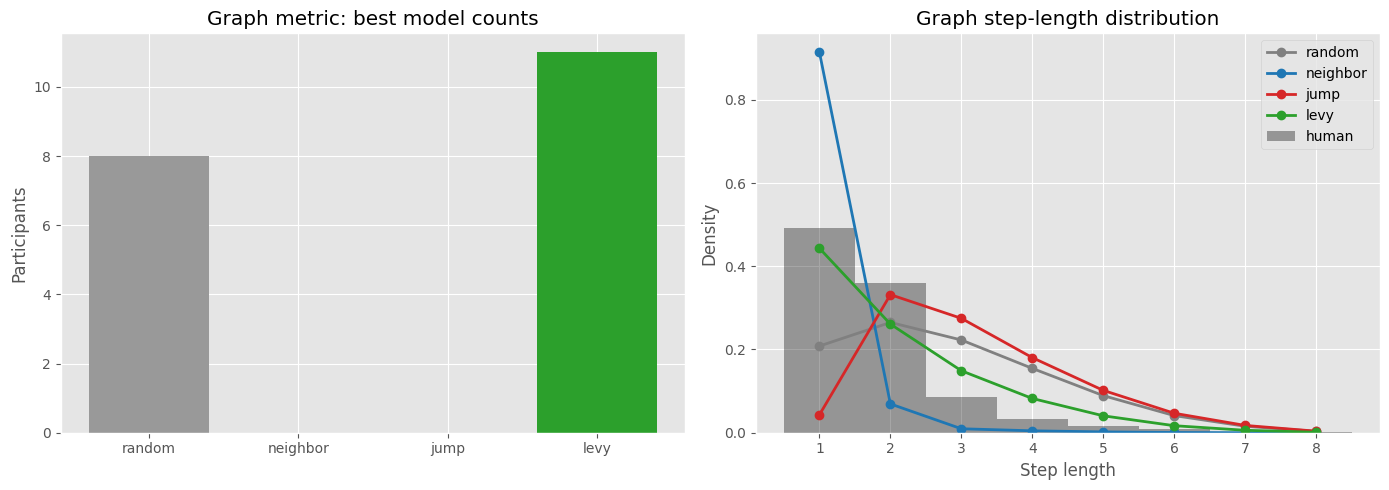

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
plot_pooled_histogram(transitions_df, graph_pooled_results, metric='graph', ax=ax)
plt.tight_layout()


In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5))
plot_step_loglikelihood_distribution(graph_step_ll, metric='graph', ax=axes, kind='box')
plt.tight_layout()


## 欧氏步长

这里的步长是两个区域质心之间的欧氏距离。

In [ ]:
euclidean_pooled_results = fit_all_models_pooled(transitions_df, metric='euclidean')
euclidean_step_ll = compute_pooled_step_loglikelihoods(transitions_df, metric='euclidean')
display(summarize_pooled_model_comparison(euclidean_pooled_results).round(4))
display(euclidean_step_ll.head().round(4))


,participant,metric,model,mu,ll,nll,aic,bic,n_steps
0,0,euclidean,random,NaN,-830.594,830.594,1661.188,1661.188,338
1,0,euclidean,levy,1.01,-884.903,884.903,1771.807,1775.630,338
2,0,euclidean,jump,NaN,-24235.129,24235.129,48470.258,48470.258,338
3,0,euclidean,neighbor,NaN,-203088.005,203088.005,406176.010,406176.010,338
4,031,euclidean,random,NaN,-1007.095,1007.095,2014.190,2014.190,399
...,...,...,...,...,...,...,...,...,...
71,赵雅菲,euclidean,neighbor,NaN,-129865.799,129865.799,259731.598,259731.598,347
72,郭lx,euclidean,random,NaN,-998.233,998.233,1996.467,1996.467,424
73,郭lx,euclidean,levy,1.01,-1140.343,1140.343,2282.686,2286.735,424
74,郭lx,euclidean,jump,NaN,-71190.143,71190.143,142380.287,142380.287,424


,participant,metric,model,mu,ll,nll,aic,bic,n_steps
0,0,euclidean,random,NaN,-830.594,830.594,1661.188,1661.188,338
1,031,euclidean,random,NaN,-1007.095,1007.095,2014.190,2014.190,399
2,24,euclidean,random,NaN,-834.351,834.351,1668.702,1668.702,331
3,311,euclidean,levy,1.971,-653.761,653.761,1309.521,1313.308,326
4,Aa,euclidean,levy,1.892,-629.811,629.811,1261.622,1265.359,310
5,FLT,euclidean,levy,1.604,-799.742,799.742,1601.483,1605.423,380
6,Rex,euclidean,levy,1.070,-775.309,775.309,1552.619,1556.427,333
7,Wangyudie,euclidean,levy,1.444,-721.396,721.396,1444.791,1448.605,335
8,cmf,euclidean,levy,1.325,-713.218,713.218,1428.437,1432.189,315
9,fzm,euclidean,levy,2.967,-426.088,426.088,854.176,857.789,274


,metric,model,count
0,euclidean,levy,11
1,euclidean,random,8


model,random,neighbor,jump,levy
participant,,,,
0,1661.19,406176.01,48470.26,1775.63
031,2014.19,359203.27,179612.10,2637.12
24,1668.70,330190.70,114584.11,1712.21
311,1665.92,237626.78,199843.63,1313.31
Aa,1599.17,223811.27,192938.08,1265.36
FLT,1881.32,321901.40,190430.51,1605.42
Rex,1701.44,283217.97,164115.80,1556.43
Wangyudie,1651.88,201706.45,249381.99,1448.61
cmf,1614.19,239008.33,183271.81,1432.19


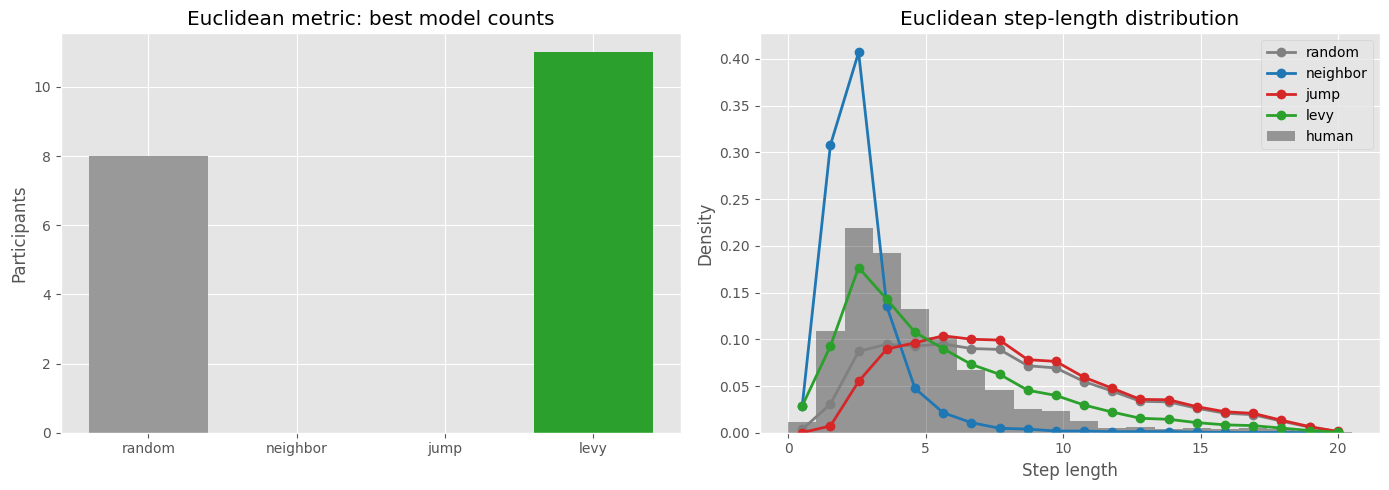

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
plot_pooled_histogram(transitions_df, euclidean_pooled_results, metric='euclidean', ax=ax)
plt.tight_layout()


In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5))
plot_step_loglikelihood_distribution(euclidean_step_ll, metric='euclidean', ax=axes, kind='box')
plt.tight_layout()


## 合并查看

下面把两种度量下的 pooled 拟合结果放在一起。

In [7]:
combined_pooled = pd.concat([graph_pooled_results, euclidean_pooled_results], ignore_index=True)
combined_pooled = combined_pooled[['metric', 'model', 'mu', 'll', 'nll', 'aic', 'bic', 'n_steps', 'avg_loglik_per_step', 'avg_likelihood_per_step']]
display(combined_pooled.sort_values(['metric', 'aic']).round(4))

combined_step_ll = pd.concat([graph_step_ll, euclidean_step_ll], ignore_index=True)
display(combined_step_ll.head().round(4))
display(
    combined_step_ll.groupby(['metric', 'model'], as_index=False)
    .agg(
        mean_loglik=('loglik', 'mean'),
        mean_likelihood=('likelihood', 'mean'),
        n_steps=('step_index', 'size'),
    )
    .sort_values(['metric', 'mean_loglik'], ascending=[True, False])
    .round(4)
)


,participant,metric,model,mu,ll,nll,aic,bic,n_steps
19,0,euclidean,random,NaN,-830.594,830.594,1661.188,1661.188,338
0,0,graph,random,NaN,-436.574,436.574,873.149,873.149,338
20,031,euclidean,random,NaN,-1007.095,1007.095,2014.190,2014.190,399
1,031,graph,random,NaN,-598.573,598.573,1197.147,1197.147,399
21,24,euclidean,random,NaN,-834.351,834.351,1668.702,1668.702,331
2,24,graph,random,NaN,-472.748,472.748,945.496,945.496,331
22,311,euclidean,levy,1.971,-653.761,653.761,1309.521,1313.308,326
3,311,graph,levy,2.160,-350.869,350.869,703.738,707.524,326
23,Aa,euclidean,levy,1.892,-629.811,629.811,1261.622,1265.359,310
4,Aa,graph,levy,2.196,-321.481,321.481,644.962,648.699,310


metric,participant,best_euclidean_model,best_graph_model
0,0,random,random
1,031,random,random
2,24,random,random
3,311,levy,levy
4,Aa,levy,levy
5,FLT,levy,levy
6,Rex,levy,levy
7,Wangyudie,levy,levy
8,cmf,levy,levy
9,fzm,levy,levy


## 如何解释结果

- 主结论看 pooled 表：这是把全部正式转移步合并后直接拟合整个分布得到的结果。
- `avg_loglik_per_step` 越大越好，`avg_likelihood_per_step` 越大越好。
- 相对 `random` 而言，`Delta LL > 0` 表示更好，`Delta AIC < 0` 和 `Delta BIC < 0` 表示更好。
- `graph_step_ll` 和 `euclidean_step_ll` 给出了每一步在各模型下的逐步 log-likelihood，可直接用于后续看分布、异常步或按 round 再拆分。